<a href="https://colab.research.google.com/github/tokiror/maple-scholars-2026/blob/main/timeseries_tanzania(mtera_and_kongwa).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import xarray
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

ds = xarray.open_dataset('GRACE-SeDA_v1_2002_2022.nc')
mjd_epoch = pd.Timestamp('1858-11-17')
dates = mjd_epoch + pd.to_timedelta(ds.time.values, unit='D')

FileNotFoundError: [Errno 2] Unable to synchronously open file (unable to open file: name = '/content/GRACE-SeDA_v1_2002_2022.nc', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0)

                 date          P1          P2          P3          P4
0 2002-04-17 12:00:00  106.691017  118.791039  114.785095  139.540741
1 2002-05-10 12:00:00  110.634872  119.623810  115.281700  128.358765
2 2002-08-16 12:00:00   25.081923   22.657181   19.328081   15.697092
3 2002-09-16 00:00:00   18.622929   15.482160   12.130322   11.437850
4 2002-10-16 12:00:00   12.749219   13.249780    6.099244    7.809370


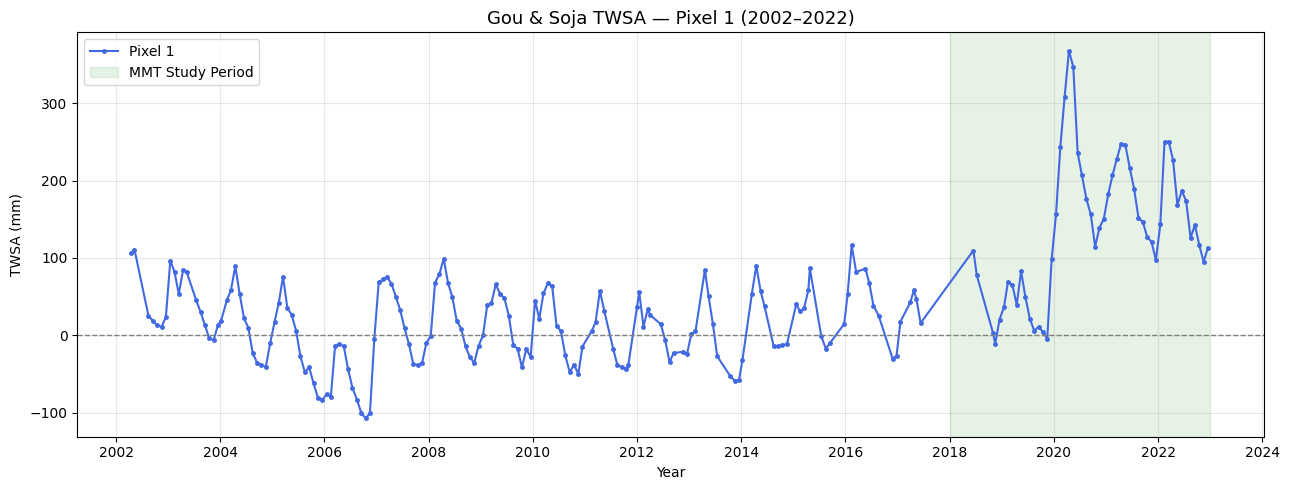

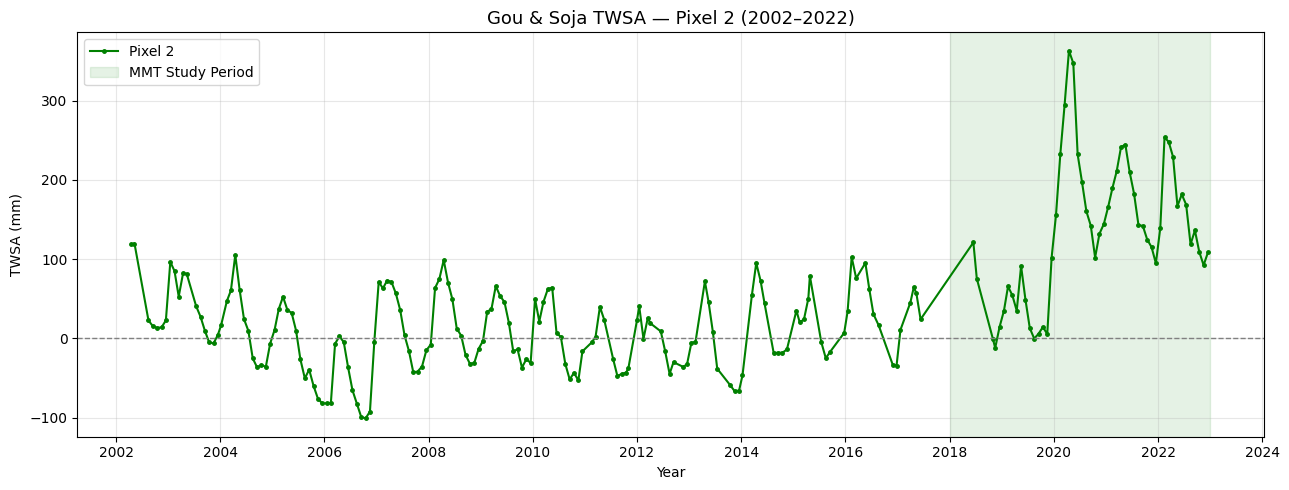

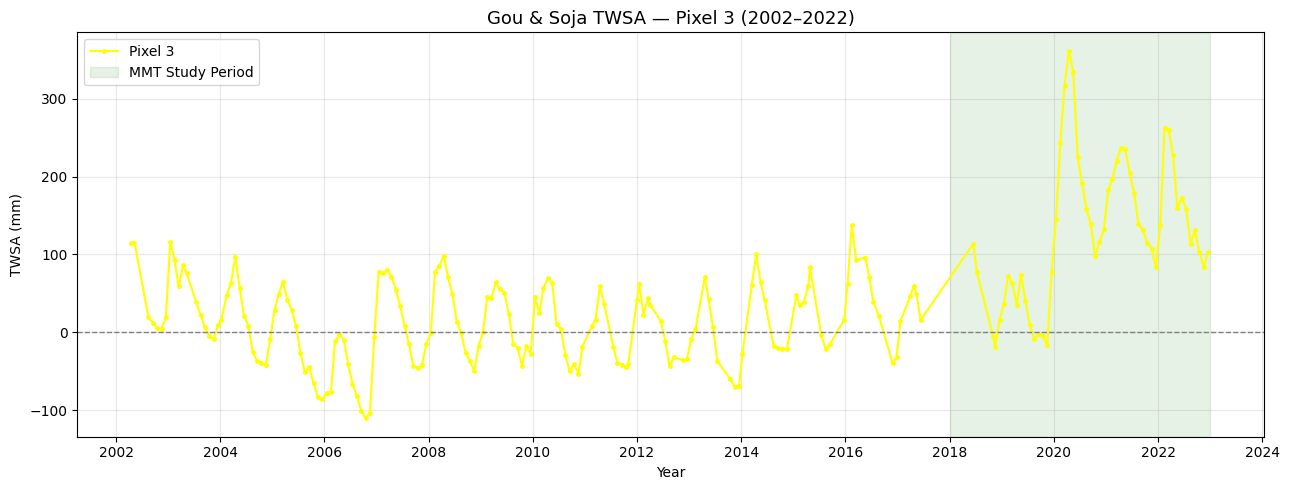

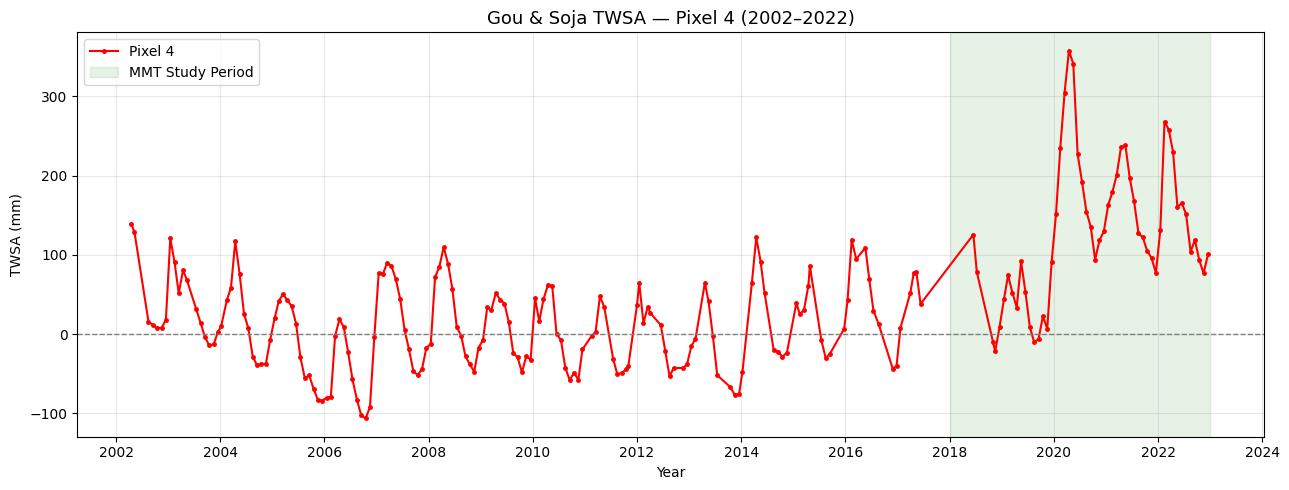

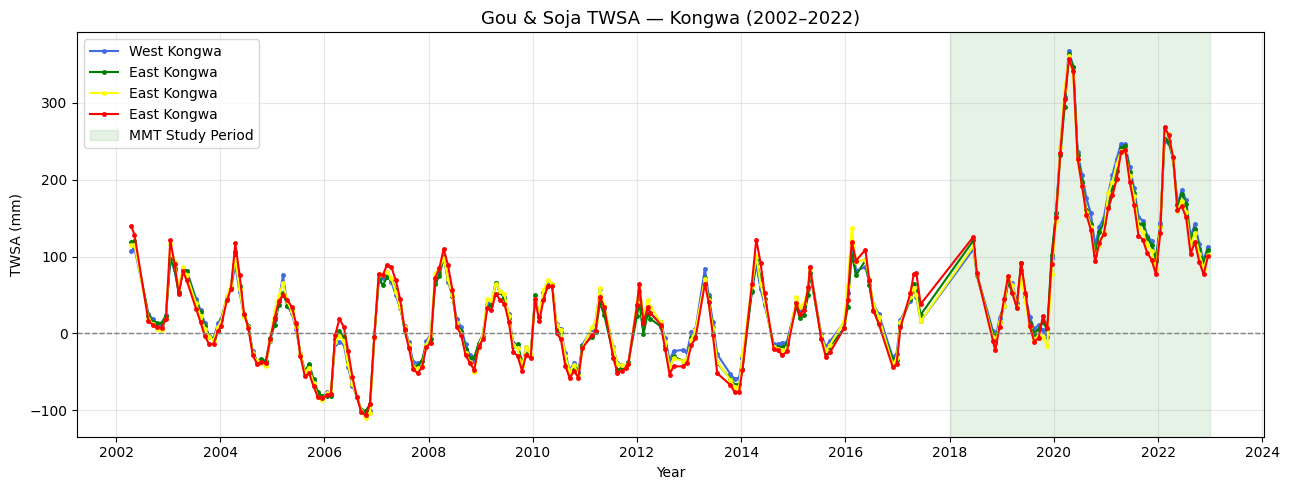

In [ ]:
#I will use a dictionaty to define the pixels and keep their coordinates seperately
def clean(series):
    return series.where((series>-1000) & (series < 1000))
p1 =  clean(ds['twsa'].sel(longitude=36.25, latitude = -5.75))
p2 =  clean(ds['twsa'].sel(longitude=36.75, latitude = -5.75))
p3 =  clean(ds['twsa'].sel(longitude=36.25, latitude = -6.25))
p4 =  clean(ds['twsa'].sel(longitude=36.75, latitude = -6.25))
df = pd.DataFrame({
    'date': dates,
    'P1': p1,
    'P2': p2,
    'P3': p3,
    'P4': p4,
})
print(df.head())

def style(ax, title):
    ax.axhline(0, color='gray', ls='--', lw=1)
    ax.axvspan(pd.Timestamp('2018-01-01'), pd.Timestamp('2022-12-31'),
               alpha=0.10, color='green', label='MMT Study Period')
    ax.set_title(title, fontsize=13)
    ax.set_xlabel('Year'); ax.set_ylabel('TWSA (mm)')
    ax.grid(True, alpha=0.3); ax.legend(fontsize=9)
    ax.xaxis.set_major_locator(mdates.YearLocator(2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
def style(ax, title):
    ax.axhline(0, color='gray', ls='--', lw=1)
    ax.axvspan(pd.Timestamp('2018-01-01'), pd.Timestamp('2022-12-31'),
               alpha=0.10, color='green', label='MMT Study Period')
    ax.set_title(title, fontsize=13)
    ax.set_xlabel('Year'); ax.set_ylabel('TWSA (mm)')
    ax.grid(True, alpha=0.3); ax.legend()
    ax.xaxis.set_major_locator(mdates.YearLocator(2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
#First graph
fig, ax = plt.subplots(figsize=(13,5))
ax.plot(df['date'], df['P1'], color='royalblue', lw=1.5, marker='o', ms=2.5,
        label='Pixel 1')
style(ax, 'Gou & Soja TWSA — Pixel 1 (2002–2022)')
plt.tight_layout(); plt.savefig('GouSoja_West_Kongwa.png', dpi=150); plt.show()

#Second plot
fig, ax = plt.subplots(figsize=(13,5))
ax.plot(df['date'], df['P2'], color='green', lw=1.5, marker='o', ms=2.5,
        label='Pixel 2')
style(ax, 'Gou & Soja TWSA — Pixel 2 (2002–2022)')
plt.tight_layout(); plt.savefig('GouSoja_West_Kongwa.png', dpi=150); plt.show()

#Third plot
fig, ax = plt.subplots(figsize=(13,5))
ax.plot(df['date'], df['P3'], color='yellow', lw=1.5, marker='o', ms=2.5,
        label='Pixel 3')
style(ax, 'Gou & Soja TWSA — Pixel 3 (2002–2022)')
plt.tight_layout(); plt.savefig('GouSoja_West_Kongwa.png', dpi=150); plt.show()

#Fourth plot
fig, ax = plt.subplots(figsize=(13,5))
ax.plot(df['date'], df['P4'], color='red', lw=1.5, marker='o', ms=2.5,
        label='Pixel 4')
style(ax, 'Gou & Soja TWSA — Pixel 4 (2002–2022)')
plt.tight_layout(); plt.savefig('GouSoja_West_Kongwa.png', dpi=150); plt.show()

#Combined plot
fig, ax = plt.subplots(figsize=(13,5))
ax.plot(df['date'], df['P1'], color='royalblue', lw=1.5, marker='o', ms=2.5, label='West Kongwa')
ax.plot(df['date'], df['P2'], color='green', lw=1.5, marker='o', ms=2.5, label='East Kongwa')
ax.plot(df['date'], df['P3'], color='yellow', lw=1.5, marker='o', ms=2.5, label='East Kongwa')
ax.plot(df['date'], df['P4'], color='red', lw=1.5, marker='o', ms=2.5, label='East Kongwa')
style(ax, 'Gou & Soja TWSA — Kongwa (2002–2022)')
plt.tight_layout(); plt.savefig('GouSoja_WestEast_Kongwa.png', dpi=150); plt.show()



In [ ]:
##Working on the time series for lake Sulunga

In [ ]:
lat_max, lat_min = -6.00, -6.500      # north to south
lon_min, lon_max = 35, 35.5     # west to east
boundary_lon = 35.5

#Bounding on Sulunga
Sulunga = ds['twsa'].sel(latitude=slice(lat_max, lat_min),
                        longitude=slice(lon_min, lon_max))
#Now lets get some actual pixel data
print("Latitudes (pixel centers):", Sulunga.latitude.values)
print("Longitudes (pixel centers):", Sulunga.longitude.values)
print("Total pixels:", Sulunga.longitude.size * Sulunga.latitude.size)

Latitudes (pixel centers): [-6.25]
Longitudes (pixel centers): [35.25]
Total pixels: 1


In [ ]:
n = 0
for la in Sulunga.latitude.values:
  for lon in Sulunga.longitude.values:
    n += 1
    side = "WEST" if lon < boundary_lon else "EAST"
    print(f"  Pixel {n}: lat {la:.3f}, lon {lon:.3f}  →  {side}")

  Pixel 1: lat -6.250, lon 35.250  →  WEST


                 date          S1
0 2002-04-17 12:00:00  118.710182
1 2002-05-10 12:00:00  113.151535
2 2002-08-16 12:00:00   23.555220
3 2002-09-16 00:00:00   13.348647
4 2002-10-16 12:00:00    3.008448


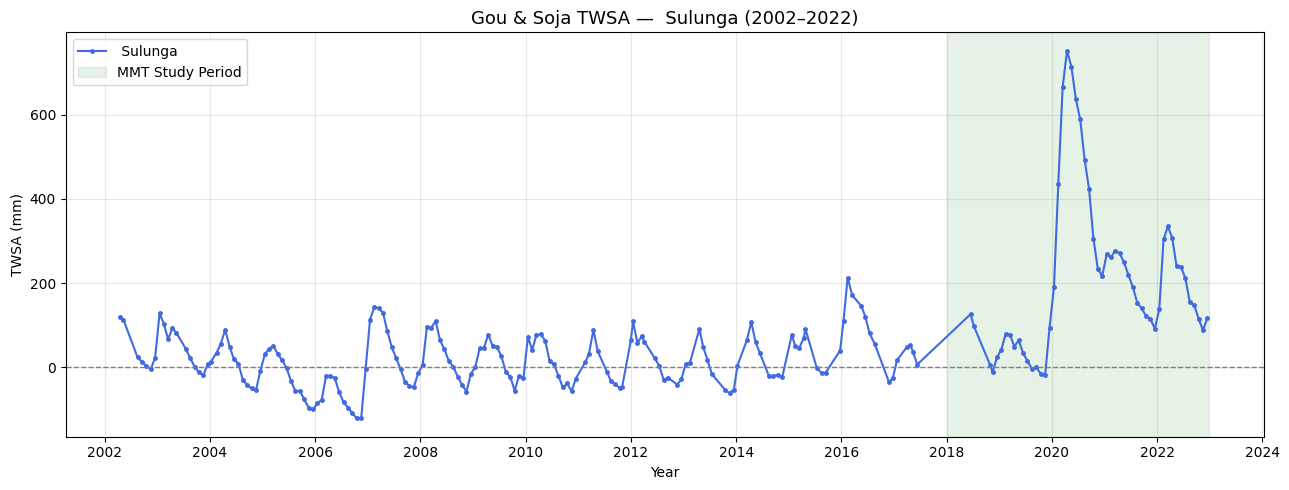

In [ ]:
def clean(series):
    return series.where((series>-1000) & (series < 1000))
s1 =  clean(ds['twsa'].sel(longitude=35.25, latitude = -6.25))
df = pd.DataFrame({
    'date': dates,
    'S1': s1,
})
print(df.head())

def style(ax, title):
    ax.axhline(0, color='gray', ls='--', lw=1)
    ax.axvspan(pd.Timestamp('2018-01-01'), pd.Timestamp('2022-12-31'),
               alpha=0.10, color='green', label='MMT Study Period')
    ax.set_title(title, fontsize=13)
    ax.set_xlabel('Year'); ax.set_ylabel('TWSA (mm)')
    ax.grid(True, alpha=0.3); ax.legend(fontsize=9)
    ax.xaxis.set_major_locator(mdates.YearLocator(2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
def style(ax, title):
    ax.axhline(0, color='gray', ls='--', lw=1)
    ax.axvspan(pd.Timestamp('2018-01-01'), pd.Timestamp('2022-12-31'),
               alpha=0.10, color='green', label='MMT Study Period')
    ax.set_title(title, fontsize=13)
    ax.set_xlabel('Year'); ax.set_ylabel('TWSA (mm)')
    ax.grid(True, alpha=0.3); ax.legend()
    ax.xaxis.set_major_locator(mdates.YearLocator(2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
# graph
fig, ax = plt.subplots(figsize=(13,5))
ax.plot(df['date'], df['S1'], color='royalblue', lw=1.5, marker='o', ms=2.5,
        label=' Sulunga')
style(ax, 'Gou & Soja TWSA —  Sulunga (2002–2022)')
plt.tight_layout(); plt.savefig('GouSoja_West_Kongwa.png', dpi=150); plt.show()

In [ ]:
##Mtera Reservoir falls under 2 pixels
lat_max, lat_min = -6.5, -7.500      # north to south
lon_min, lon_max = 35.5, 36.00     # west to east
boundary_lon = 35.5

#Bounding on Sulunga
Mtera = ds['twsa'].sel(latitude=slice(lat_max, lat_min),
                        longitude=slice(lon_min, lon_max))
#Now lets get some actual pixel data
print("Latitudes (pixel centers):", Mtera.latitude.values)
print("Longitudes (pixel centers):", Mtera.longitude.values)
print("Total pixels:", Mtera.longitude.size * Mtera.latitude.size)
n = 0
for la in Mtera.latitude.values:
  for lon in Mtera.longitude.values:
    n += 1
    side = "North" if lon < boundary_lon else "South"
    print(f"  Pixel {n}: lat {la:.3f}, lon {lon:.3f}  →  {side}")

Latitudes (pixel centers): [-6.75 -7.25]
Longitudes (pixel centers): [35.75]
Total pixels: 2
  Pixel 1: lat -6.750, lon 35.750  →  South
  Pixel 2: lat -7.250, lon 35.750  →  South


In [ ]:
def clean(series):
    return series.where((series>-1000) & (series < 1000))
m1 =  clean(ds['twsa'].sel(longitude=35.75, latitude = -6.75))
m2 =  clean(ds['twsa'].sel(longitude=35.75, latitude = -7.25))
df = pd.DataFrame({
    'date': dates,
    'M1': m1,
    'M2': m2,
})
print(df.head())
print("Are M1 and M2 identical?", (df['M1'].fillna(0) == df['M2'].fillna(0)).all())

                 date          M1          M2
0 2002-04-17 12:00:00  122.149048  102.998077
1 2002-05-10 12:00:00  118.264893  101.300575
2 2002-08-16 12:00:00   18.192518   -5.795738
3 2002-09-16 00:00:00    9.358136   -4.483109
4 2002-10-16 12:00:00   -0.720050  -14.491530
Are M1 and M2 identical? False


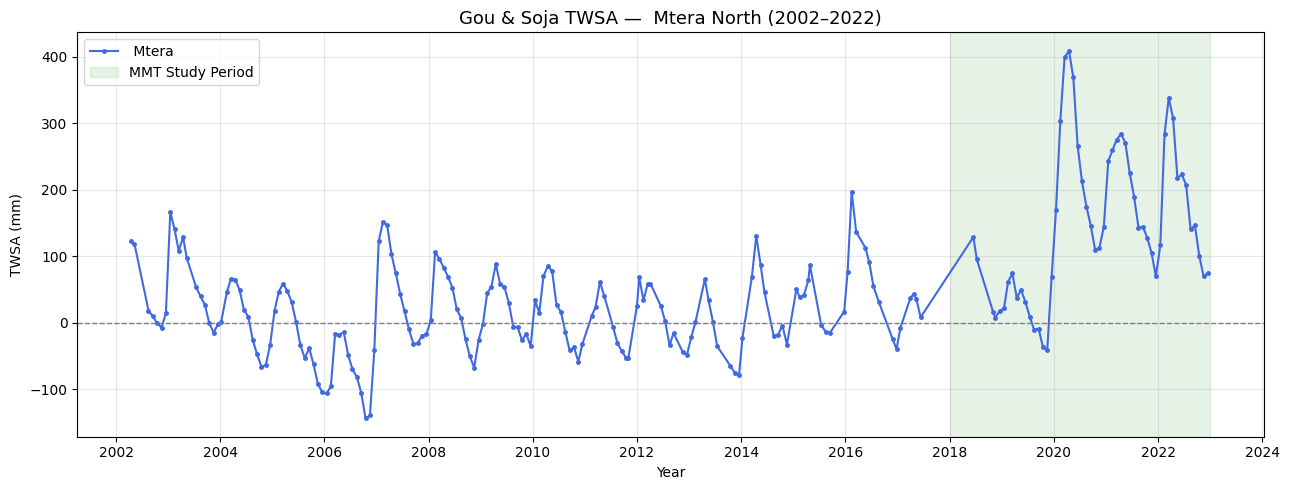

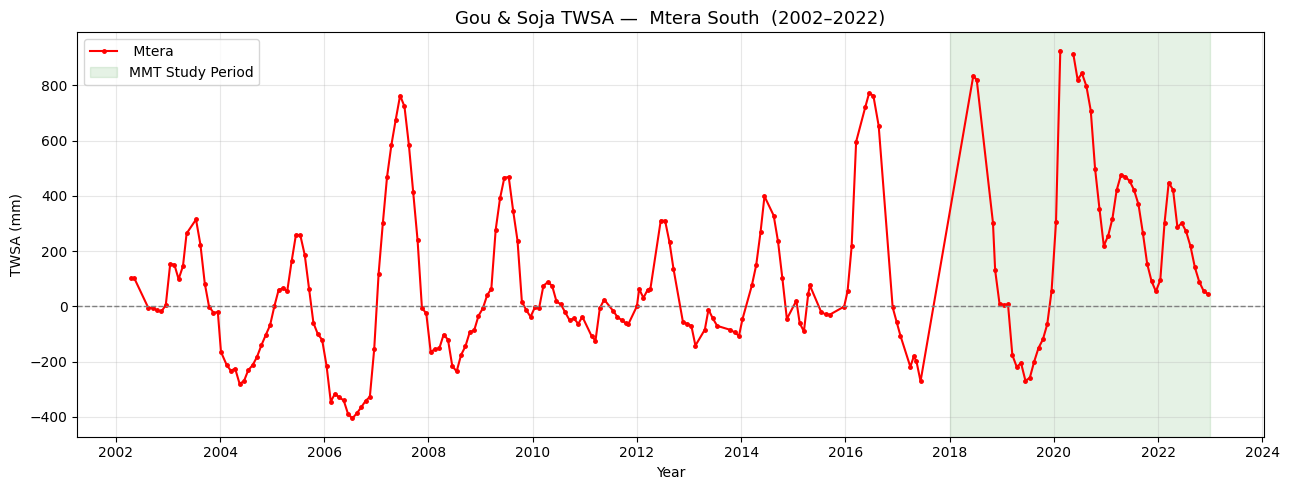

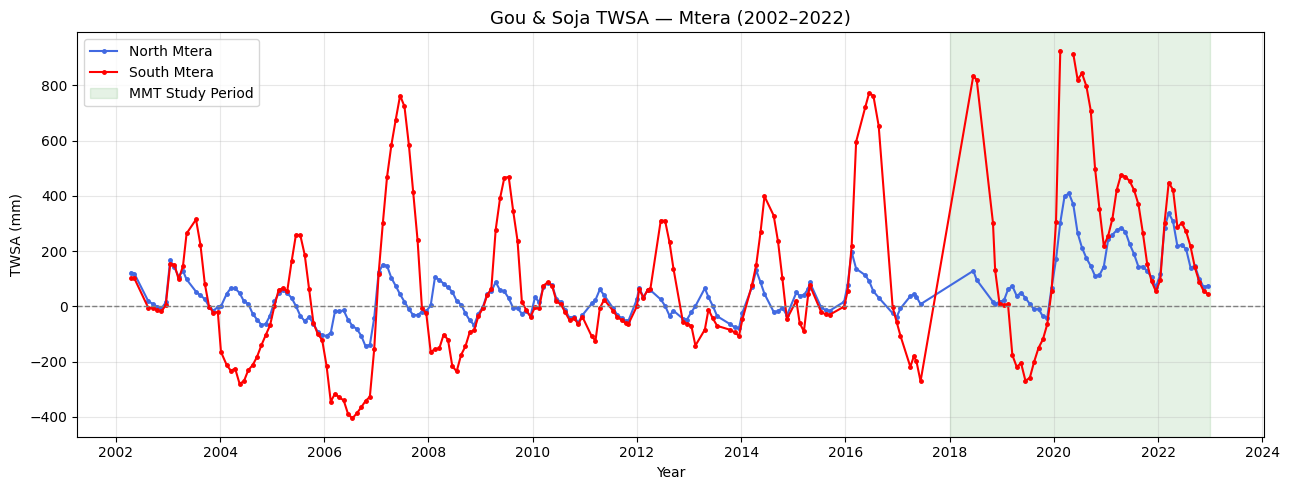

In [ ]:
def style(ax, title):
    ax.axhline(0, color='gray', ls='--', lw=1)
    ax.axvspan(pd.Timestamp('2018-01-01'), pd.Timestamp('2022-12-31'),
               alpha=0.10, color='green', label='MMT Study Period')
    ax.set_title(title, fontsize=13)
    ax.set_xlabel('Year'); ax.set_ylabel('TWSA (mm)')
    ax.grid(True, alpha=0.3); ax.legend(fontsize=9)
    ax.xaxis.set_major_locator(mdates.YearLocator(2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
def style(ax, title):
    ax.axhline(0, color='gray', ls='--', lw=1)
    ax.axvspan(pd.Timestamp('2018-01-01'), pd.Timestamp('2022-12-31'),
               alpha=0.10, color='green', label='MMT Study Period')
    ax.set_title(title, fontsize=13)
    ax.set_xlabel('Year'); ax.set_ylabel('TWSA (mm)')
    ax.grid(True, alpha=0.3); ax.legend()
    ax.xaxis.set_major_locator(mdates.YearLocator(2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
# graph1
fig, ax = plt.subplots(figsize=(13,5))
ax.plot(df['date'], df['M1'], color='royalblue', lw=1.5, marker='o', ms=2.5,
        label=' Mtera')
style(ax, 'Gou & Soja TWSA —  Mtera North (2002–2022)')
plt.tight_layout(); plt.savefig('Mtera North .png', dpi=150); plt.show()

fig, ax = plt.subplots(figsize=(13,5))
ax.plot(df['date'], df['M2'], color='red', lw=1.5, marker='o', ms=2.5,
        label=' Mtera')
style(ax, 'Gou & Soja TWSA —  Mtera South  (2002–2022)')
plt.tight_layout(); plt.savefig('Mtera South.png', dpi=150); plt.show()



#Combined plot
fig, ax = plt.subplots(figsize=(13,5))
ax.plot(df['date'], df['M1'], color='royalblue', lw=1.5, marker='o', ms=2.5, label='North Mtera')
ax.plot(df['date'], df['M2'], color='red', lw=1.5, marker='o', ms=2.5, label='South Mtera')
style(ax, 'Gou & Soja TWSA — Mtera (2002–2022)')
plt.tight_layout(); plt.savefig('Mtera Combined.png', dpi=150); plt.show()